In [103]:
from cProfile import label
from operator import index
import string
from turtle import title
from wsgiref.simple_server import sys_version
import SimpleITK as sitk
import numpy as np
import numpy.ma as ma
from matplotlib import pyplot
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
import seaborn as sns


In [5]:
url = "D:\\data\\Aaron\\ProstateMRL\\Data\\Extraction\\Mean_values\\Raw\\Datafiles\\20fractions.csv"
df_all = pd.read_csv(url)
df_all

,Unnamed: 0,PatID,ScanDate,Scan,Observer,Region,Mean,Std
0,0,213,2011-04-03,17,AR,Muscle,27.766486,91.210657
1,1,213,2011-04-03,17,RP,Prostate,57.517336,37.853825
2,2,213,2011-04-03,18,AR,Muscle,27.249620,92.712686
3,3,213,2011-04-03,18,RP,Prostate,54.065658,34.524047
4,4,213,2011-04-03,19,AR,Muscle,26.330139,93.448889
...,...,...,...,...,...,...,...,...
160,160,312108,2019-10-18,62,AR,Muscle,34.918521,114.228247
161,161,312108,2019-10-18,62,RP,Prostate,69.887691,39.465957
162,162,312108,2019-10-18,63,AR,Muscle,35.126491,113.963033
163,163,312108,2019-10-18,63,MA,Prostate,72.361964,42.827301


In [23]:
patIDs = df_all.PatID.unique

df_all["ScanDate"] = pd.to_datetime(df_all["ScanDate"], dayfirst=True)

df_all




,Unnamed: 0,PatID,ScanDate,Scan,Observer,Region,Mean,Std
0,0,213,2011-04-03,17,AR,Muscle,27.766486,91.210657
1,1,213,2011-04-03,17,RP,Prostate,57.517336,37.853825
2,2,213,2011-04-03,18,AR,Muscle,27.249620,92.712686
3,3,213,2011-04-03,18,RP,Prostate,54.065658,34.524047
4,4,213,2011-04-03,19,AR,Muscle,26.330139,93.448889
...,...,...,...,...,...,...,...,...
160,160,312108,2019-10-18,62,AR,Muscle,34.918521,114.228247
161,161,312108,2019-10-18,62,RP,Prostate,69.887691,39.465957
162,162,312108,2019-10-18,63,AR,Muscle,35.126491,113.963033
163,163,312108,2019-10-18,63,MA,Prostate,72.361964,42.827301


In [29]:
patIDs = df_all.PatID.unique()
#patIDs = [653]
print(patIDs)
#numPat = patIDs.size()

for i in patIDs:
    pat = [str(i)]
    pat_df = df_all.loc[df_all["PatID"] == i]
    #pat_df = df_all[df_all["PatID"].isin([213])]

    print(pat_df.head())

    firstScan = pat_df["ScanDate"].min()
    pat_df["DaysFromFrac1"] = pat_df["ScanDate"] - firstScan
    pat_df["DaysFromFrac1"] = pd.to_numeric(pat_df["DaysFromFrac1"].dt.days, downcast="integer")
    pat_df = pat_df.sort_values(by=["DaysFromFrac1"])


[   213    231    257    292    626    695   1464 106958 251842 312108]
   Unnamed: 0  PatID   ScanDate  Scan Observer    Region       Mean        Std
0           0    213 2011-04-03    17       AR    Muscle  27.766486  91.210657
1           1    213 2011-04-03    17       RP  Prostate  57.517336  37.853825
2           2    213 2011-04-03    18       AR    Muscle  27.249620  92.712686
3           3    213 2011-04-03    18       RP  Prostate  54.065658  34.524047
4           4    213 2011-04-03    19       AR    Muscle  26.330139  93.448889
    Unnamed: 0  PatID   ScanDate  Scan Observer    Region       Mean  \
30          30    231 2011-03-20    19       AR    Muscle  29.008479   
31          31    231 2011-03-20    19       RP  Prostate  84.616990   
32          32    231 2011-03-16     3       AR    Muscle  29.971193   
33          33    231 2011-03-16     3       RP  Prostate  71.480530   
34          34    231 2011-03-27    34       AR    Muscle  29.327406   

          Std  
30  6

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


No handles with labels found to put in legend.


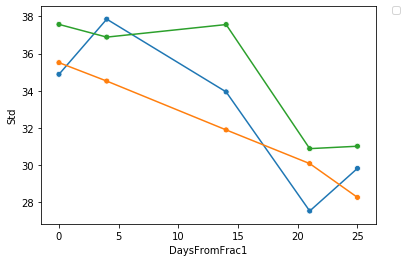

In [145]:
pat_213 = pd.read_csv( "D:\\data\\Aaron\\ProstateMRL\\Data\\Extraction\\Mean_values\\Raw\\Datafiles\\213.csv")
pat_213

pros = pat_213.query("Region == 'Prostate'")
muscle = pat_213.query("Region == 'Muscle'")

sns.lineplot(data=pros, x="DaysFromFrac1", y="Std", hue="ScanType", legend=False)
sns.scatterplot(data=pros, x="DaysFromFrac1", y="Std", hue="ScanType", legend=False)


plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)



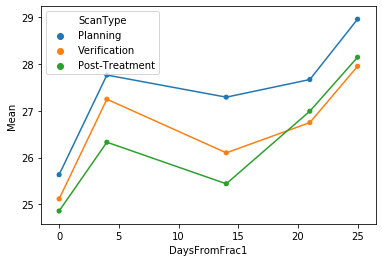

In [144]:
sns.lineplot(data=muscle, x="DaysFromFrac1", y="Mean", hue="ScanType", legend=False)
sns.scatterplot(data=muscle, x="DaysFromFrac1", y="Mean", hue="ScanType")

    Unnamed: 0  Unnamed: 0.1  PatID   ScanDate  Scan Observer    Region  \
0           38            38    653 2011-12-07     6       AR    Muscle   
1           39            39    653 2011-12-07     6       MA  Prostate   
2           40            40    653 2011-12-07     6       RP  Prostate   
3           41            41    653 2011-12-07     7       AR    Muscle   
4           42            42    653 2011-12-07     7       MA  Prostate   
5           43            43    653 2011-12-07     7       RP  Prostate   
6           44            44    653 2011-12-07     8       AR    Muscle   
7           45            45    653 2011-12-07     8       JZ  Prostate   
8           46            46    653 2011-12-07     8       MA  Prostate   
9           47            47    653 2011-12-07     8       RP  Prostate   
10           0             0    653 2011-12-11    14       AR    Muscle   
11           1             1    653 2011-12-11    14       MA  Prostate   
12           2           

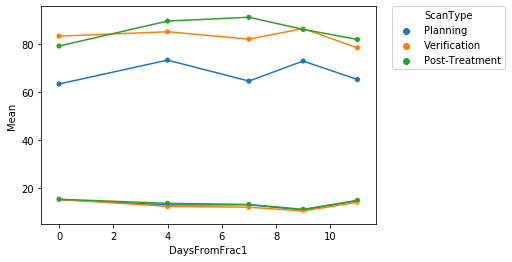

In [146]:
pat_653 = pd.read_csv("D:\\data\\Aaron\\ProstateMRL\\Data\\Extraction\\Mean_values\\Raw\\Datafiles\\653.csv")
pat_653
initials = "MA"
pros = pat_653.query("Observer == 'MA'")
muscle = pat_653.query("Observer =='AR'")

firstScan = pat_653["ScanDate"].min()
pat_653["ScanDate"] = pd.to_datetime(pat_653["ScanDate"], dayfirst=True)
pat_653["DaysFromFrac1"] = pat_653["ScanDate"] - pd.to_datetime(firstScan, dayfirst=True)
pat_653["DaysFromFrac1"] = pd.to_numeric(pat_653["DaysFromFrac1"].dt.days, downcast="integer")

print(pat_653)

pros = pat_653.query("Observer == 'MA'")
muscle = pat_653.query("Observer =='AR'")
sns.lineplot(data=pros, x="DaysFromFrac1", y="Mean", hue="ScanType", legend=False)
sns.scatterplot(data=pros, x="DaysFromFrac1", y="Mean", hue="ScanType", legend=False)
sns.lineplot(data=muscle, x="DaysFromFrac1", y="Mean", hue="ScanType", legend=False)
sns.scatterplot(data=muscle, x="DaysFromFrac1", y="Mean", hue="ScanType")

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)



In [152]:
pat_842 = df_all.query("PatID == '312108'")
pat_108 = pat_842.query("Region == 'Prostate'")
pat_108.sort_values(by="Scan")

,Unnamed: 0,PatID,ScanDate,Scan,Observer,Region,Mean,Std
142,142,312108,2019-09-23,3,MA,Prostate,67.795716,45.186725
143,143,312108,2019-09-23,3,RP,Prostate,66.316549,43.366265
151,151,312108,2019-09-23,4,RP,Prostate,62.473061,42.390346
153,153,312108,2019-09-24,5,RP,Prostate,61.670805,42.995070
136,136,312108,2019-09-30,19,RP,Prostate,75.119390,41.863315
138,138,312108,2019-09-30,20,RP,Prostate,77.166909,40.976233
140,140,312108,2019-10-01,21,RP,Prostate,63.095749,43.123675
145,145,312108,2019-10-07,35,RP,Prostate,63.883232,40.099893
147,147,312108,2019-10-07,36,RP,Prostate,75.389228,39.730205
149,149,312108,2019-10-08,37,RP,Prostate,64.861449,37.277444
